# Autoencoder for Image Denoising — MNIST PNG Dataset

**Dataset:** [MNIST Dataset by awsaf49 on Kaggle](https://www.kaggle.com/datasets/awsaf49/mnist-dataset)


## Step 1: Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import cv2                          # for reading PNG images
from glob import glob               # for finding all image file paths

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping

print('All libraries imported')

2026-06-27 05:20:21.130686: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782537621.461440      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782537621.550646      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782537622.278677      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782537622.278721      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782537622.278723      58 computation_placer.cc:177] computation placer alr

All libraries imported


## Step 2: Check Dataset Folder Structure

In [2]:
# Dataset root path on Kaggle
DATA_ROOT = '/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png'

TRAIN_DIR = os.path.join(DATA_ROOT, 'training')
TEST_DIR  = os.path.join(DATA_ROOT, 'testing')

# Check the folder structure
print('Training folders (one per digit):')
train_folders = sorted(os.listdir(TRAIN_DIR))
for folder in train_folders:
    folder_path = os.path.join(TRAIN_DIR, folder)
    n_images    = len(os.listdir(folder_path))
    print(f'   {folder}/ → {n_images} images')

print()
print('Testing folders (one per digit):')
test_folders = sorted(os.listdir(TEST_DIR))
for folder in test_folders:
    folder_path = os.path.join(TEST_DIR, folder)
    n_images    = len(os.listdir(folder_path))
    print(f'   {folder}/ → {n_images} images')

Training folders (one per digit):
   0/ → 5923 images
   1/ → 6742 images
   2/ → 5958 images
   3/ → 6131 images
   4/ → 5842 images
   5/ → 5421 images
   6/ → 5918 images
   7/ → 6265 images
   8/ → 5851 images
   9/ → 5949 images

Testing folders (one per digit):
   0/ → 980 images
   1/ → 1135 images
   2/ → 1032 images
   3/ → 1010 images
   4/ → 982 images
   5/ → 892 images
   6/ → 958 images
   7/ → 1028 images
   8/ → 974 images
   9/ → 1009 images


## Step 3: Load PNG Images into NumPy Arrays

In [3]:
def load_images_from_folder(root_dir):
    images = []
    labels = []

    digit_folders = sorted(os.listdir(root_dir))  

    for digit in digit_folders:
        folder_path = os.path.join(root_dir, digit)

        if not os.path.isdir(folder_path):
            continue

        for img_file in os.listdir(folder_path):
            if not img_file.lower().endswith('.png'):
                continue

            img_path = os.path.join(folder_path, img_file)

            # Read image as grayscale (28×28)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Resize to 28×28 just in case (should already be 28×28)
            img = cv2.resize(img, (28, 28))

            # Normalize: 
            img = img.astype('float32') / 255.0

            img = np.expand_dims(img, axis=-1)

            images.append(img)
            labels.append(int(digit))

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int32')

    return images, labels


# Load training and testing images
print('Loading training images')
x_train, y_train = load_images_from_folder(TRAIN_DIR)
print(f'   x_train shape : {x_train.shape}')    # (60000, 28, 28, 1)
print(f'   y_train shape : {y_train.shape}')    # (60000,)

print('Loading testing images')
x_test, y_test = load_images_from_folder(TEST_DIR)
print(f'   x_test shape  : {x_test.shape}')     # (10000, 28, 28, 1)
print(f'   y_test shape  : {y_test.shape}')     # (10000,)

print()
print(f'Pixel range: min = {x_train.min():.2f}  |  max = {x_train.max():.2f}')
print('Images loaded successfully ')

Loading training images
   x_train shape : (60000, 28, 28, 1)
   y_train shape : (60000,)
Loading testing images
   x_test shape  : (10000, 28, 28, 1)
   y_test shape  : (10000,)

Pixel range: min = 0.00  |  max = 1.00
Images loaded successfully 


## Step 4: Visualise Sample Clean Images

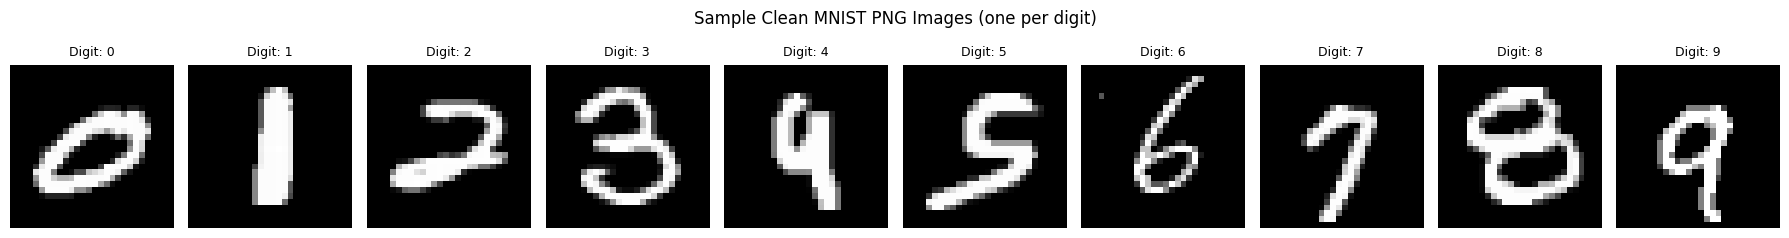

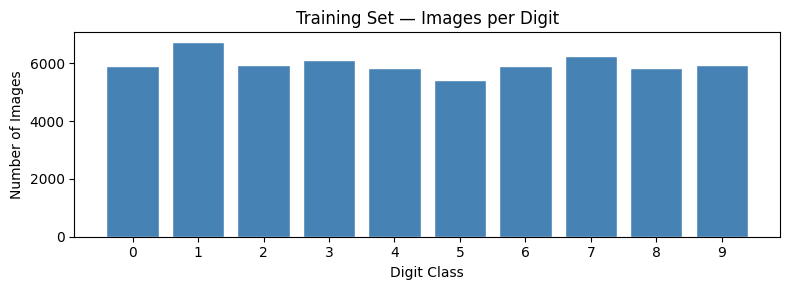

In [4]:
# Show one image from each digit class (0–9)
fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
fig.suptitle('Sample Clean MNIST PNG Images (one per digit)', fontsize=12)

for digit in range(10):
    # Find first image of this digit
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(x_train[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[digit].set_title(f'Digit: {digit}', fontsize=9)
    axes[digit].axis('off')

plt.tight_layout()
plt.show()

# Show class distribution
fig, ax = plt.subplots(figsize=(8, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Digit Class')
ax.set_ylabel('Number of Images')
ax.set_title('Training Set — Images per Digit')
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()

## Step 5: aussian Noise to Images

Noise factor      : 0.5
x_train_noisy     : (60000, 28, 28, 1)
x_test_noisy      : (10000, 28, 28, 1)


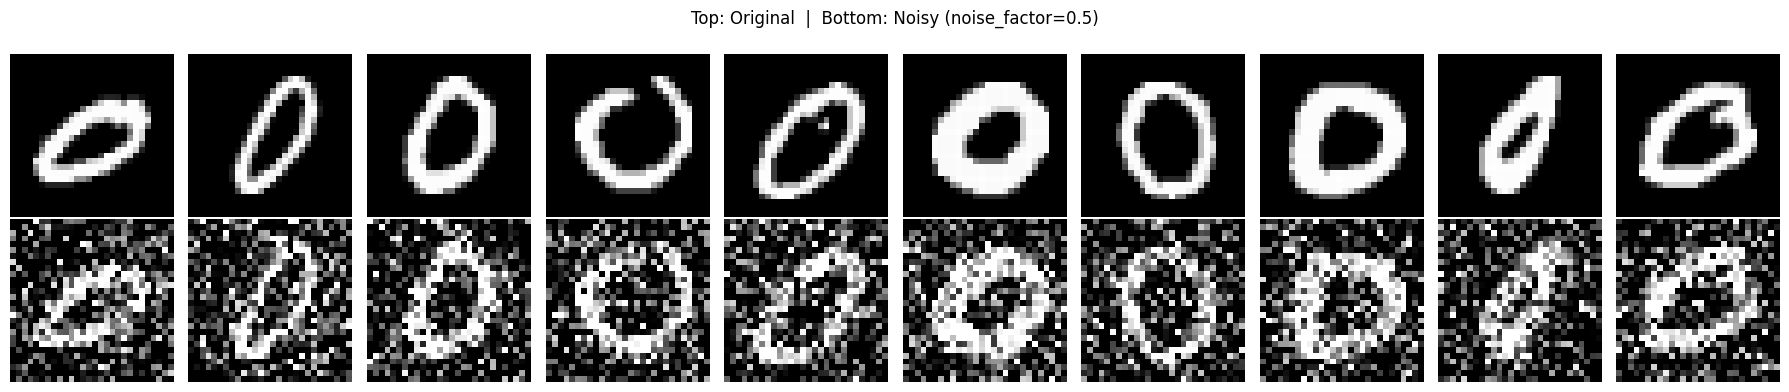

In [5]:
NOISE_FACTOR = 0.5 

def add_noise(images, noise_factor=0.5):

    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise
    noisy = np.clip(noisy, 0.0, 1.0)   # clamp to valid range
    return noisy.astype('float32')


# Create noisy versions
x_train_noisy = add_noise(x_train, NOISE_FACTOR)
x_test_noisy  = add_noise(x_test,  NOISE_FACTOR)

print(f'Noise factor      : {NOISE_FACTOR}')
print(f'x_train_noisy     : {x_train_noisy.shape}')
print(f'x_test_noisy      : {x_test_noisy.shape}')

# Visualise clean vs noisy
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle(f'Top: Original  |  Bottom: Noisy (noise_factor={NOISE_FACTOR})', fontsize=12)

for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(),       cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=10, color='green')
axes[1, 0].set_ylabel('Noisy', fontsize=10, color='red')
plt.tight_layout()
plt.show()

## Step 6: Build the Convolutional Autoencoder

In [6]:
def build_autoencoder(input_shape=(28, 28, 1)):
    inputs = Input(shape=input_shape, name='noisy_input')

    # Block 1: detect basic edges and curves
    x = layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', name='enc_conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same',
                            name='enc_pool1')(x)         

    # Block 2: detect digit shapes
    x = layers.Conv2D(64, (3, 3), activation='relu',
                      padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2, 2), padding='same',
                            name='enc_pool2')(x)          

    # Block 3: expand back
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu',
                               padding='same', name='dec_conv1')(x)
    x = layers.UpSampling2D((2, 2), name='dec_up1')(x)     

    # Block 4: refine
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu',
                               padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_up2')(x)     
    # Output: sigmoid 
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid',
                            padding='same', name='clean_output')(x)   

    model = models.Model(inputs, outputs, name='denoising_autoencoder')
    return model


# Build
autoencoder = build_autoencoder(input_shape=(28, 28, 1))

autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

autoencoder.summary()

2026-06-27 05:35:44.333987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train the Model

In [7]:
EPOCHS = 20
BATCH_SIZE = 128

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print('Training started')
print(f'Epochs: {EPOCHS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Noise factor: {NOISE_FACTOR}')
print()

history = autoencoder.fit(
    x_train_noisy, 
    x_train,         
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

print()
print('Training complete')

Training started
Epochs: 20
Batch size: 128
Noise factor: 0.5

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 133ms/step - loss: 0.1128 - mae: 0.1343 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete


## Step 8: Plot Training History

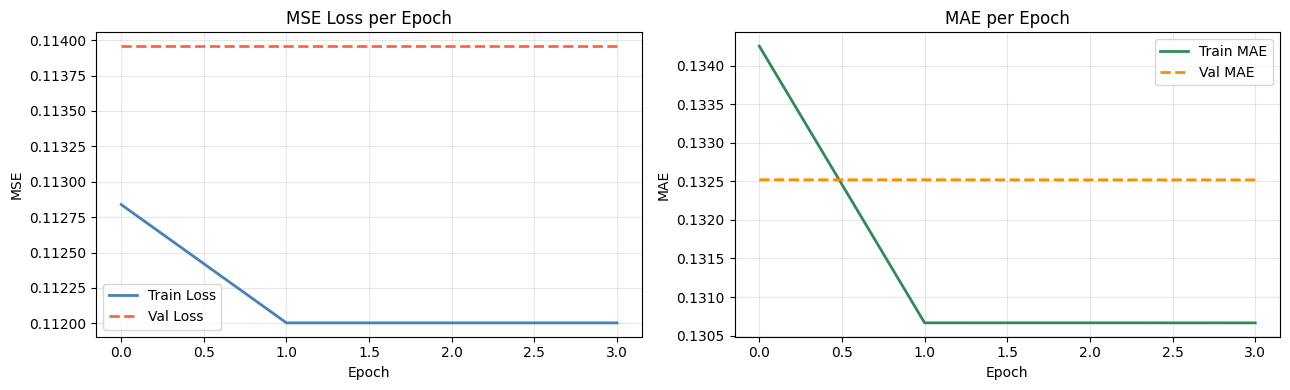

Best epoch    : 1
Best val_loss : 0.11396


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MSE Loss
axes[0].plot(history.history['loss'],     label='Train Loss',
             linewidth=2, color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',
             linewidth=2, color='tomato', linestyle='--')
axes[0].set_title('MSE Loss per Epoch', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE',
             linewidth=2, color='seagreen')
axes[1].plot(history.history['val_mae'], label='Val MAE',
             linewidth=2, color='darkorange', linestyle='--')
axes[1].set_title('MAE per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch    = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
print(f'Best epoch    : {best_epoch}')
print(f'Best val_loss : {best_val_loss:.5f}')

## Step 9: Generate Denoised Predictions

In [9]:
# Pass noisy test images through the trained autoencoder
print('Generating denoised images')
x_test_denoised = autoencoder.predict(x_test_noisy, verbose=1)

print(f'Output shape: {x_test_denoised.shape}')  
print(f'Output pixel range: [{x_test_denoised.min():.3f}, {x_test_denoised.max():.3f}]')
print('Predictions done')

Generating denoised images
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Output shape: (10000, 28, 28, 1)
Output pixel range: [0.000, 0.013]
Predictions done


## Step 10: Evaluate: MSE and PSNR

  Noisy MSE: 0.11548 | PSNR: 9.38 dB
  Denoised MSE: 0.11396 | PSNR: 9.43 dB
  Gain MSE: 0.00152 | PSNR: +0.06 dB


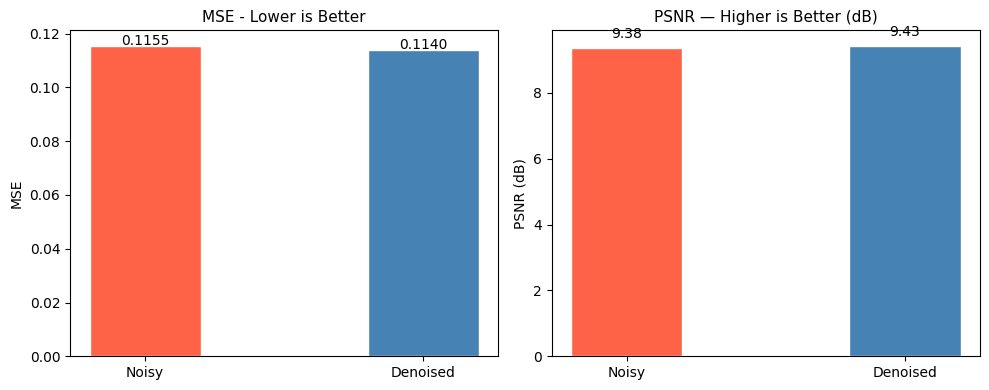

In [10]:
def compute_metrics(images, reference):
    mse  = float(np.mean((images.astype('float32') - reference.astype('float32')) ** 2))
    psnr = 10.0 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    return mse, psnr

mse_n, psnr_n = compute_metrics(x_test_noisy,    x_test)
mse_d, psnr_d = compute_metrics(x_test_denoised, x_test)

print(f'  Noisy MSE: {mse_n:.5f} | PSNR: {psnr_n:.2f} dB')
print(f'  Denoised MSE: {mse_d:.5f} | PSNR: {psnr_d:.2f} dB')
print(f'  Gain MSE: {mse_n - mse_d:.5f} | PSNR: +{psnr_d - psnr_n:.2f} dB')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Noisy', 'Denoised'], [mse_n, mse_d],
            color=['tomato', 'steelblue'], width=0.4, edgecolor='white')
axes[0].set_title('MSE - Lower is Better', fontsize=11)
axes[0].set_ylabel('MSE')
for i, v in enumerate([mse_n, mse_d]):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(['Noisy', 'Denoised'], [psnr_n, psnr_d],
            color=['tomato', 'steelblue'], width=0.4, edgecolor='white')
axes[1].set_title('PSNR — Higher is Better (dB)', fontsize=11)
axes[1].set_ylabel('PSNR (dB)')
for i, v in enumerate([psnr_n, psnr_d]):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 11 - Visualise: Original vs Noisy vs Denoised

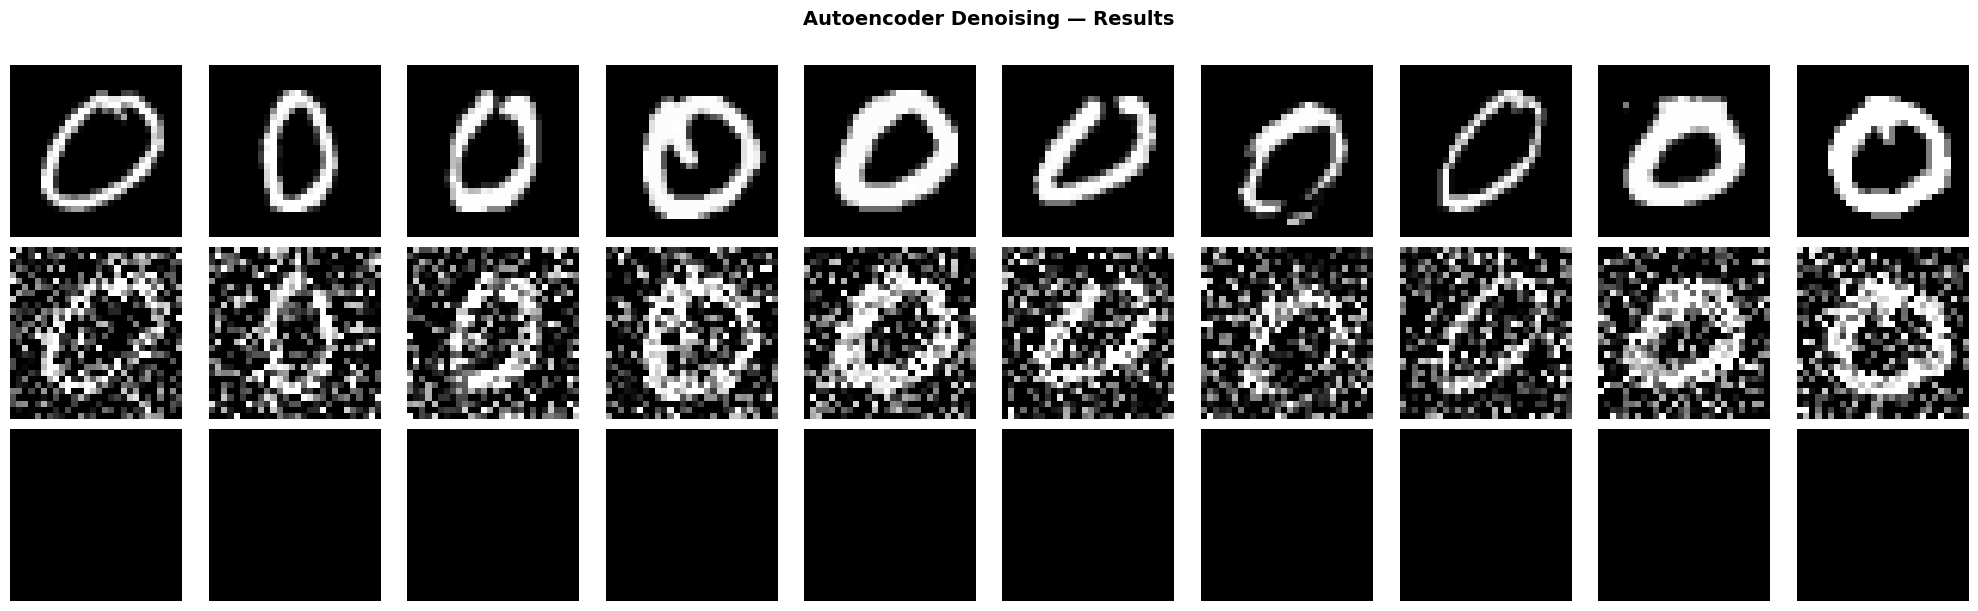

In [11]:
n = 10   # number of sample images to show

fig, axes = plt.subplots(3, n, figsize=(20, 6))
fig.suptitle('Autoencoder Denoising — Results', fontsize=14, fontweight='bold', y=1.01)

rows = [
    (x_test,'Original','green'),
    (x_test_noisy,'Noisy Input','red'),
    (x_test_denoised,'Denoised Output','blue'),
]

for row_idx, (imgs, label, color) in enumerate(rows):
    for col_idx in range(n):
        ax = axes[row_idx, col_idx]
        ax.imshow(imgs[col_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=11, color=color,
                          rotation=90, labelpad=50, va='center')

plt.tight_layout()
plt.show()

## Step 12: Test with Different Noise Levels

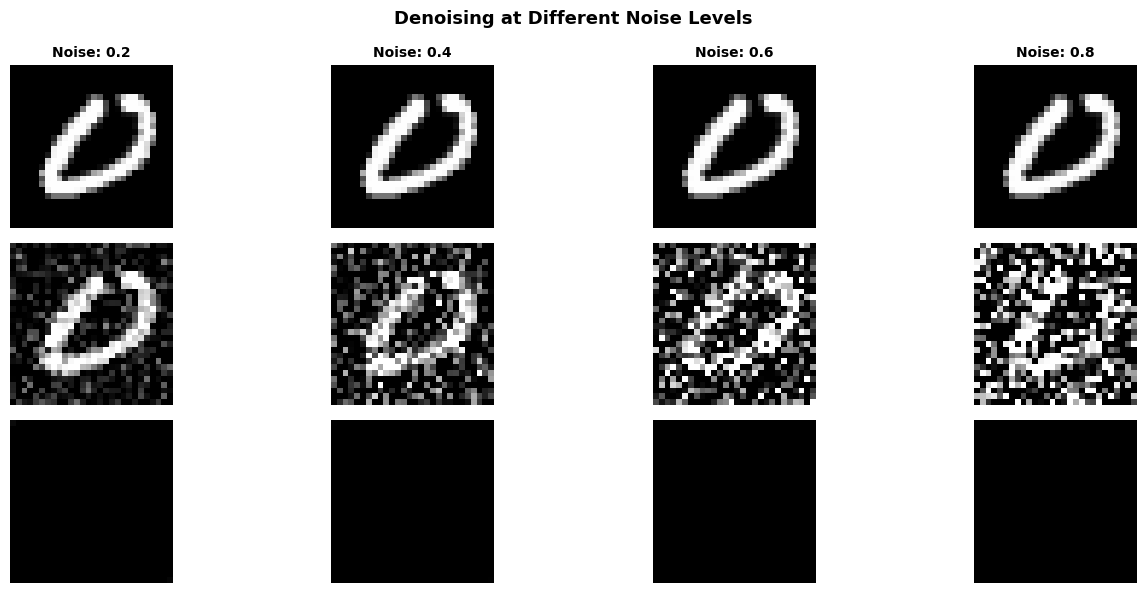

In [12]:
noise_levels = [0.2, 0.4, 0.6, 0.8]
sample_idx   = 5   # which test image to use

fig, axes = plt.subplots(3, len(noise_levels), figsize=(14, 6))
fig.suptitle('Denoising at Different Noise Levels', fontsize=13, fontweight='bold')

for col, nf in enumerate(noise_levels):
    noisy_img    = add_noise(x_test[[sample_idx]], nf)
    denoised_img = autoencoder.predict(noisy_img, verbose=0)

    axes[0, col].imshow(x_test[sample_idx].squeeze(),  cmap='gray', vmin=0, vmax=1)
    axes[1, col].imshow(noisy_img[0].squeeze(),        cmap='gray', vmin=0, vmax=1)
    axes[2, col].imshow(denoised_img[0].squeeze(),     cmap='gray', vmin=0, vmax=1)

    axes[0, col].set_title(f'Noise: {nf}', fontsize=10, fontweight='bold')
    for row in range(3):
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, color='green')
axes[1, 0].set_ylabel('Noisy',    fontsize=10, color='red')
axes[2, 0].set_ylabel('Denoised', fontsize=10, color='blue')

plt.tight_layout()
plt.show()

## Step 13: Save the Trained Model

In [13]:
SAVE_PATH = '/kaggle/working/denoising_autoencoder.keras'
autoencoder.save(SAVE_PATH)
print(f'Model saved → {SAVE_PATH}')

Model saved → /kaggle/working/denoising_autoencoder.keras
